# ECON526: Problem Set 4

Jesse Perla (University of British Columbia)

## Student Name/Number: (doubleclick to edit)

### Instructions

- Ensure you modify the field above with your **name and student number above immediately**
- Modify directly and do not rename the file as Canvas will automatically append your name to it.
- Submit both the `.ipynb` and an exported `html` version of this file.
- See [here](https://jlperla.github.io/grad_econ_datascience/pages/canvas_assignments.html) for instructions.
- Do not change the filenames. Canvas automatically appends your name/student number to submitted files.

## Setup

Feel free to use the following packages (and we have added a few convenience imports)

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.special import expit
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import confusion_matrix, precision_score, recall_score
from sklearn.cluster import KMeans, SpectralClustering
np.random.seed(526)

def data_path(name):
    url = "https://jlperla.github.io/grad_econ_datascience/slides/data/"
    local = f"../slides/data/{name}"
    return local if os.path.exists(local) else url + name

## Question 1

Take the simulated data from the classification lecture: two features, a logistic data generating process, and $N = 500$ observations.

In [2]:
N = 500
X = np.random.randn(N, 2)
beta_true = np.array([1.5, -1.0])
p_true = expit(0.3 + X @ beta_true)
y = (np.random.rand(N) < p_true).astype(int)
clf = LogisticRegression(C=np.inf).fit(X, y)
print(f"intercept {clf.intercept_[0]:.3f}, "
      f"coefficients {clf.coef_[0].round(3)}")

intercept 0.109, coefficients [ 1.445 -0.92 ]

### Question 1.1

Plot the data with the two classes in different colors and add the decision boundary of the fitted model, i.e. the line where $\hat{p}(x) = 1/2$. Hint: solve $\hat{\beta}_0 + \hat{\beta}_1 x_1 + \hat{\beta}_2 x_2 = 0$ for $x_2$.

In [3]:
# modify here

### Question 1.2

Use `clf.predict_proba` to get $\hat{p}(x_n)$ for every observation. For thresholds $\tau \in \{0.2, 0.5, 0.8\}$ form $\hat{y}_n = \mathbf{1}\left\{{\hat{p}(x_n) > \tau}\right\}$ and report the confusion matrix, precision, and recall. Check that $\tau = 0.5$ reproduces `clf.predict`.

In [5]:
# modify here

### Question 1.3

Describe how precision and recall move as $\tau$ rises and explain why, in terms of which observations change their predicted class. Then suppose a false negative costs four times as much as a false positive. Which $\tau$ minimizes expected cost, and why?

### Answer:

**(double click to edit your answer)**

## Question 2

The classification lecture classified job titles into $22$ SOC occupation groups. Here we make it a binary problem: is a title in the **Healthcare Practitioners and Technical** group or not? About $9\%$ of the O\*NET titles are.

In [7]:
onet = pd.read_csv(data_path("onet_titles.csv.gz"))
target = "Healthcare Practitioners and Technical"
onet["health"] = (onet["major_group_title"] == target).astype(int)
print(f"share healthcare: {onet['health'].mean():.3f}")
titles_tr, titles_te, y_tr, y_te = train_test_split(
    onet["title"], onet["health"], test_size=0.25, random_state=526)
vec = CountVectorizer()
X_tr = vec.fit_transform(titles_tr)
X_te = vec.transform(titles_te)

share healthcare: 0.090

### Question 2.1

Fit a `LogisticRegression(max_iter=1000)` on the training word counts. On the held-out titles report the confusion matrix, accuracy, precision, recall, the false positive rate, and the false negative rate. Then report the accuracy of a rule that predicts “not healthcare” for every title. Which of those numbers tell you the classifier is useful, and which do not?

In [8]:
# modify here

### Answer:

**(double click to edit your answer)**

### Question 2.2

Print the ten words with the largest positive coefficients and the five with the most negative. Hint: `vec.get_feature_names_out()` gives the vocabulary in the order of the columns of `X_tr`. Do they make sense?

In [10]:
# modify here

### Answer:

**(double click to edit your answer)**

### Question 2.3

Recall was low at $\tau = 1/2$. Recompute precision and recall on the held-out titles with $\tau = 0.2$. Then apply the classifier to the Chicago payroll titles and list the distinct job titles with $\hat{p}$ between $0.3$ and $0.7$. Look at those titles. What makes them hard for the occupation classifier, and would you trust the SOC occupation group it assigns to them?

In [12]:
chicago = pd.read_csv(data_path("chicago_payroll.csv.gz"))
# modify here

### Answer:

**(double click to edit your answer)**

## Question 3

### Question 3.1

The clustering example in class worked quite well. Modify the example to make it perform worse and briefly explain why.

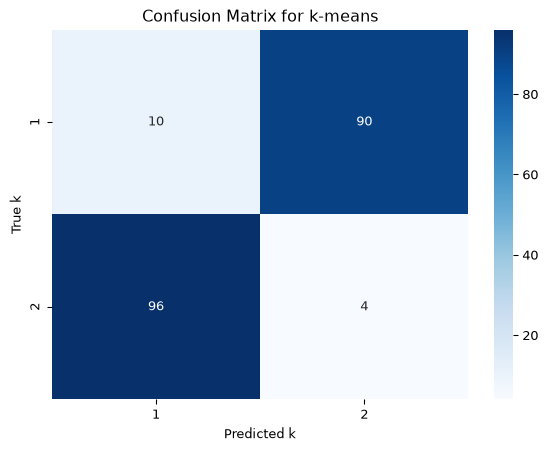

In [14]:
# MODIFY CODE HERE for your example
mu_1 = np.array([0.0, 0.0]) # mean of k=1
mu_2 = np.array([1.0, 1.0]) # mean of k=2
sigma = np.array([[0.2, 0], [0, 0.2]]) # use same variance
N = 100 # observations per group
X_1 = np.random.multivariate_normal(mu_1, sigma, N)
X_2 = np.random.multivariate_normal(mu_2, sigma, N)
df_1 = pd.DataFrame({"f1": X_1[:, 0], "f2": X_1[:, 1], "k": 1})
df_2 = pd.DataFrame({"f1": X_2[:, 0], "f2": X_2[:, 1], "k": 2})
df = pd.concat([df_1, df_2], ignore_index=True)
kmeans = KMeans(n_clusters=2, random_state=0)
df["k_hat"] = kmeans.fit_predict(df[["f1", "f2"]]) + 1
cm = confusion_matrix(df["k"], df["k_hat"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[1, 2], yticklabels=[1, 2])
plt.xlabel("Predicted k")
plt.ylabel("True k")
plt.title("Confusion Matrix for k-means")
plt.show()

### Answer:

**(double click to edit your answer)**

### Question 3.2

Repeat Q3.1, but change a different parameter to make it perform worse in a different way. Briefly explain why.

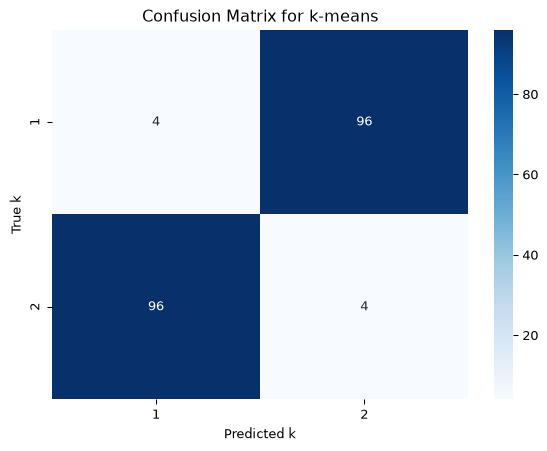

In [16]:
# MODIFY CODE HERE for your example
mu_1 = np.array([0.0, 0.0]) # mean of k=1
mu_2 = np.array([1.0, 1.0]) # mean of k=2
sigma = np.array([[0.2, 0], [0, 0.2]]) # use same variance
N = 100 # observations per group
X_1 = np.random.multivariate_normal(mu_1, sigma, N)
X_2 = np.random.multivariate_normal(mu_2, sigma, N)
df_1 = pd.DataFrame({"f1": X_1[:, 0], "f2": X_1[:, 1], "k": 1})
df_2 = pd.DataFrame({"f1": X_2[:, 0], "f2": X_2[:, 1], "k": 2})
df = pd.concat([df_1, df_2], ignore_index=True)
kmeans = KMeans(n_clusters=2, random_state=0)
df["k_hat"] = kmeans.fit_predict(df[["f1", "f2"]]) + 1
cm = confusion_matrix(df["k"], df["k_hat"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[1, 2], yticklabels=[1, 2])
plt.xlabel("Predicted k")
plt.ylabel("True k")
plt.title("Confusion Matrix for k-means")
plt.show()

### Answer:

**(double click to edit your answer)**

### Question 3.3

Generate three groups and pretend you do not know $K$. Fit `KMeans(n_clusters=K, random_state=0)` for $K = 1, \ldots, 8$, record the within-cluster sum of squares (the `inertia_` attribute of the fitted object), and plot it against $K$. Where is the elbow, and why does the curve keep falling after it?

In [18]:
mu = [np.array([0.0, 0.0]), np.array([3.0, 0.0]), np.array([1.5, 2.5])]
X_3 = np.vstack([mu_k + 0.6 * np.random.randn(100, 2) for mu_k in mu])
# modify here

### Answer:

**(double click to edit your answer)**

## Question 4

### Question 4.1

Take the following example of generated data and latents

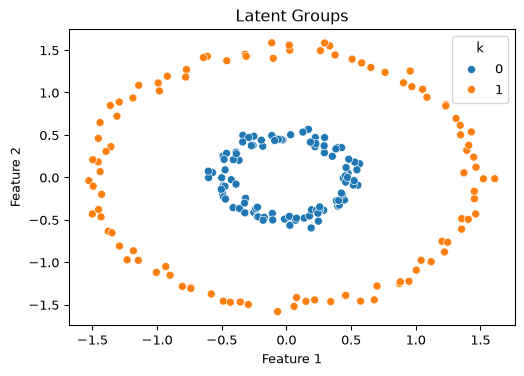

In [20]:
def generate_noisy_circle(radius, num_points, noise_std):
    theta = np.linspace(0, 2 * np.pi, num_points)
    x = radius * np.cos(theta) + np.random.normal(0, noise_std, num_points)
    y = radius * np.sin(theta) + np.random.normal(0, noise_std, num_points)
    return np.column_stack((x, y))

X_1 = generate_noisy_circle(0.5, 100, 0.05)
X_2 = generate_noisy_circle(1.5, 100, 0.05)
df_1 = pd.DataFrame({"f1": X_1[:, 0], "f2": X_1[:, 1], "k": 0})
df_2 = pd.DataFrame({"f1": X_2[:, 0], "f2": X_2[:, 1], "k": 1})
df = pd.concat([df_1, df_2], ignore_index=True)
fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(data=df, x="f1", y="f2", hue="k", ax=ax)
ax.set(xlabel="Feature 1", ylabel="Feature 2", title="Latent Groups")
plt.show()

Note that the `k=0` and `k=1` states are fully separated and the difference is visually obvious. Now perform k-means clustering

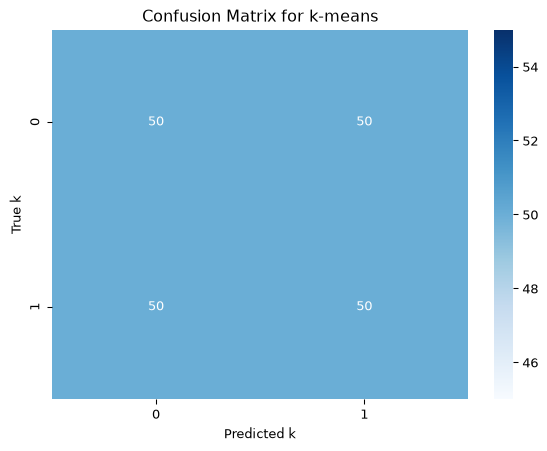

In [21]:
kmeans = KMeans(n_clusters=2, random_state=0)
df["k_hat"] = kmeans.fit_predict(df[["f1", "f2"]])
cm = confusion_matrix(df["k"], df["k_hat"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted k")
plt.ylabel("True k")
plt.title("Confusion Matrix for k-means")
plt.show()

Can you explain why this was a failure using your knowledge of k-means clustering? Be precise if possible.

### Answer:

**(double click to edit your answer)**

### Question 4.2

But all is not lost! Look at the results of the following code which uses a different algorithm

/home/runner/work/grad_econ_datascience/grad_econ_datascience/.venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(

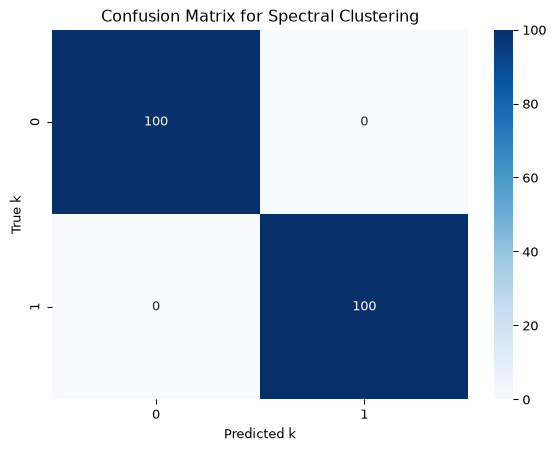

In [22]:
spectral = SpectralClustering(n_clusters=2, affinity="nearest_neighbors",
                              random_state=0)
df["k_hat"] = spectral.fit_predict(df[["f1", "f2"]])
cm = confusion_matrix(df["k"], df["k_hat"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicted k")
plt.ylabel("True k")
plt.title("Confusion Matrix for Spectral Clustering")
plt.show()

Look up [spectral clustering](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.SpectralClustering.html) in the scikit-learn docs and provide a two sentence summary of why this worked.

### Answer:

**(double click to edit your answer)**